# Text Preprocessing

Tugas 2 mengolah 200 artikel detik.com (100 sport, 100 finance) dari
`dataset_berita_detik.csv` yang dikumpulkan pada Tugas 1. Tujuannya mengubah
teks mentah menjadi angka yang siap diproses: teks dieksplorasi, dibersihkan,
dibakukan, dilabeli kategori kata, lalu dipetakan ke vektor TF-IDF dan diringkas
dengan PCA..



## Eksplorasi Awal

Sebelum transformasi, data diperiksa untuk mencari anomali: kelengkapan baris
dan label, sebaran panjang teks per label, karakter di luar ASCII, serta sisa
antarmuka situs. Temuan di sini menjadi dasar aturan pembersihan pada seksi
berikutnya.

In [1]:
import pandas as pd

df = pd.read_csv("dataset_berita_detik.csv")

checks = pd.DataFrame({
    "pemeriksaan": ["jumlah baris", "nilai kosong", "baris ganda",
                    "URL ganda", "urutan id", "jumlah per label"],
    "hasil": [len(df), df.isna().sum().sum(), df.duplicated().sum(),
              df["url"].duplicated().sum(),
              "lengkap 1-200" if list(df["id"]) == list(range(1, len(df) + 1))
              else "tidak urut",
              "; ".join(f"{k}: {v}"
                        for k, v in df["label"].value_counts().items())],
})
checks

,pemeriksaan,hasil
0,jumlah baris,200
1,nilai kosong,0
2,baris ganda,0
3,URL ganda,0
4,urutan id,lengkap 1-200
5,jumlah per label,sport: 100; finance: 100


In [2]:
df[["id", "label", "url"]].head()

,id,label,url
0,1,sport,https://sport.detik.com/moto-gp/d-8666386/marc...
1,2,sport,https://sport.detik.com/fotosport/d-8666341/me...
2,3,sport,https://sport.detik.com/moto-gp/d-8666308/ai-o...
3,4,sport,https://sport.detik.com/g-sport/d-8666151/ketu...
4,5,sport,https://sport.detik.com/sport-lain/d-8666068/u...


### Length by Label

Panjang karakter dan jumlah kata dirangkum per label, lalu digambar sebagai
diagram kotak. Perbandingan ini menunjukkan apakah teks sport dan finance
berbeda jauh sebelum diproses.

In [3]:
stats = (df.assign(panjang_karakter=df["isi_berita"].str.len(),jumlah_kata=df["isi_berita"].str.split().str.len())
         .groupby("label")[["panjang_karakter", "jumlah_kata"]]
         .agg(["min", "median", "max"]))
stats

panjang_karakter               jumlah_kata            
                     min  median   max         min median  max
label                                                         
finance              224  2331.0  7078          31  326.0  953
sport                246  2026.5  7149          35  294.5  974

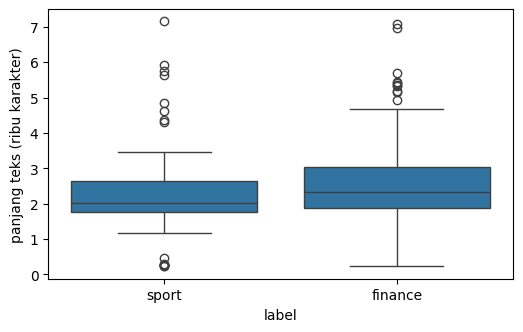

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=df, x="label", y=df["isi_berita"].str.len() / 1000, ax=ax)
ax.set_ylabel("panjang teks (ribu karakter)")
plt.show()

### Character Inventory

Karakter di luar ASCII (misal aksen hasil transliterasi nama, tanda kutip
melengkung, atau emoji) diinventarisasi dulu. Aksen seperti é atau tanda hubung
non-ASCII akan dianggap karakter asing saat tokenisasi, jadi setiap kemunculannya
dinormalisasi ke padanan ASCII.

In [5]:
def chars_outside_ascii(text):
    return sorted({c for c in text if ord(c) > 127})


rows = []
for _, r in df.iterrows():
    extra = chars_outside_ascii(r["isi_berita"])
    if extra:
        rows.append({"id": r["id"], 
                     "label": r["label"],
                     "karakter": " ".join(extra)})
character_inventory = pd.DataFrame(
    rows,
    columns=["id", "label", "karakter"]
)

display(character_inventory)

,id,label,karakter
0,36,sport,— ™ 🇲 🇸 🏁 🤯
1,46,sport,— ™ 🇲 🇸 🏁 😱
2,47,sport,— ™ 🇲 🇸 🏁 🏆
3,197,finance,•


In [6]:
import unicodedata


def normalize_letters(text):
    decomposed = unicodedata.normalize("NFD", text)
    text = "".join(c for c in decomposed if not unicodedata.combining(c))
    return text.replace("\u2011", "-").replace("\u2010", "-")


def around_first(text, window=30):
    pos = next(i for i, c in enumerate(text) if ord(c) > 127)
    return text[max(0, pos - window):pos + window]


ids = [r["id"] for r in rows][:6]
sample = df.set_index("id").loc[ids, "isi_berita"]
pd.DataFrame({
    "id": sample.index,
    "sebelum": [around_first(t) for t in sample],
    "sesudah": [normalize_letters(around_first(t)) for t in sample],
})

,id,sebelum,sesudah
0,36,nges in the #MotoGP standings 🤯#SanMarinoGP 🇸🇲...,nges in the #MotoGP standings 🤯#SanMarinoGP 🇸🇲...
1,46,a kalinya. EARLY EARLY DRAMA! — MotoGP™🏁 (@Mot...,a kalinya. EARLY EARLY DRAMA! — MotoGP™🏁 (@Mot...
2,47,k musim MotoGP 2026 bergulir. 🏆 @marcmarquez93...,k musim MotoGP 2026 bergulir. 🏆 @marcmarquez93...
3,197,"ejumlah manfaat, antara lain: • Perlindungan P...","ejumlah manfaat, antara lain: • Perlindungan P..."


### Boilerplate Check

Artikel hasil crawling membawa sisa antarmuka detik.com: penutup
`Anda menyukai artikel ini Artikel disimpan`, kode redaksi dalam kurung seperti
`(krs/nds)`, dan artikel foto yang hanya berisi keterangan pendek dengan awalan
`Foto Sport`. Sisa seperti ini muncul di hampir semua dokumen sehingga tidak
membedakan kelas, jadi dicacah dulu sebelum diputuskan untuk dibuang.

In [7]:
from collections import Counter

tail = Counter(" ".join(t.split()[-6:]) for t in df["isi_berita"])
pd.DataFrame(tail.most_common(5), columns=["enam kata terakhir", "jumlah"])

,enam kata terakhir,jumlah
0,Anda menyukai artikel ini Artikel disimpan,197
1,"9,5%,"" pungkasnya. Saksikan Live DetikPagi: (f...",1
2,pihak Summarecon. Saksikan Live DetikPagi: (ah...,1
3,"dibiarin mangkrak begitu,"" jelas Dony (hrp/hns)",1


In [8]:
byline_re = r"\(\w{2,6}(?:/\w{2,6})+\)"
boiler_re = rf"(?:{byline_re}\s*)?Anda menyukai artikel ini\s+Artikel disimpan\s*$"
photo_re = r"^Foto\s+(?:Sport|Finance)\s+"

texts = df["isi_berita"]
n_boiler = int(texts.str.contains(boiler_re).sum())

pd.DataFrame({
    "pola": ["penutup 'Anda menyukai artikel ini'", "kode redaksi (krs/nds)",
             "awalan 'Foto Sport' atau 'Foto Finance'",
             "teks di bawah 500 karakter"],
    "jumlah artikel": [n_boiler, int(texts.str.contains(byline_re).sum()),
                       int(texts.str.contains(photo_re).sum()),
                       int((texts.str.len() < 500).sum())],
})

,pola,jumlah artikel
0,penutup 'Anda menyukai artikel ini',197
1,kode redaksi (krs/nds),61
2,awalan 'Foto Sport' atau 'Foto Finance',7
3,teks di bawah 500 karakter,12


### Boilerplate Removal

Penutup, kode redaksi, dan awalan foto dibuang dari teks. Awalan `Foto Sport`
ikut dibuang karena kata *sport* sama persis dengan nama label, sehingga bisa
menjadi petunjuk palsu bagi model. Perubahan dibuktikan lewat ujung teks
sebelum dan sesudah, lalu dicek bahwa tidak ada sisa penutup di seluruh korpus.

In [9]:
import re


def strip_boilerplate(text):
    text = re.sub(photo_re, "", text)
    return re.sub(boiler_re, "", text).strip()


sample = df["isi_berita"].head(3)
cleaned = sample.map(strip_boilerplate)
pd.DataFrame({
    "id": df["id"].head(3),
    "sebelum": [f"{t[:30]} ... {t[-55:]}" for t in sample],
    "sesudah": [f"{t[:30]} ... {t[-55:]}" for t in cleaned],
})

,id,sebelum,sesudah
0,1,Marc Marquez Disebut di Puncak ... n. (krs/nds...,Marc Marquez Disebut di Puncak ... arco Bezzec...
1,2,Foto Sport Melihat dari Dekat ... ar prestasi...,Melihat dari Dekat Latihan Par ... tan fisik m...
2,3,"Ai Ogura Siap Comeback di Moto ... ."" (krs/ran...",Ai Ogura Siap Comeback di Moto ... ani balapan...


In [10]:
df["isi_berita"] = df["isi_berita"].map(strip_boilerplate)
df["isi_berita"].str.contains("Anda menyukai artikel ini").sum()

np.int64(0)

## Number & Punctuation Removal

Angka dan tanda baca tidak dianggap sebagai term, sehingga dipotong kasar dari
teks. Pemotongan seperti itu meninggalkan artefak: token satu huruf, dua huruf,
URL, lambang mata uang, komposit berangka, dan angka Romawi. Artefak dicacah
dulu, lalu diputuskan satu per satu berdasarkan konteksnya.

### Naive Token Count

Pemotongan kasar dibuat dulu: huruf dikecilkan dan semua selain huruf diganti
spasi sebelum token dihitung. Angka ini menjadi pembanding seberapa banyak
token hilang setelah artefak dibuang.

In [11]:
def naive_tokens(text):
    return re.sub(r"[^a-z\s]", " ", text.lower()).split()


naive = [w for doc in df["isi_berita"] for w in naive_tokens(doc)]
naive_counts = Counter(naive)
single = {w: n for w, n in naive_counts.items() if len(w) == 1}
double = {w: n for w, n in naive_counts.items() if len(w) == 2}

pd.DataFrame({
    "metrik": ["token total", "kata unik", "token satu huruf",
               "token dua huruf"],
    "jumlah": [len(naive), len(naive_counts), sum(single.values()),
               sum(double.values())],
    "proporsi": ["100%", f"{100 * len(naive_counts) / len(naive):.2f}%",
                 f"{100 * sum(single.values()) / len(naive):.2f}%",
                 f"{100 * sum(double.values()) / len(naive):.2f}%"],
})

,metrik,jumlah,proporsi
0,token total,64919,100%
1,kata unik,7311,11.26%
2,token satu huruf,240,0.37%
3,token dua huruf,2773,4.27%


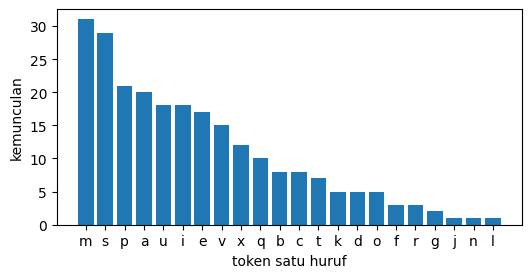

In [12]:
fig, ax = plt.subplots(figsize=(6, 2.8))
freq = sorted(single.items(), key=lambda x: -x[1])
ax.bar([w for w, _ in freq], [n for _, n in freq])
ax.set_xlabel("token satu huruf")
ax.set_ylabel("kemunculan")
plt.show()

### Single-Letter Guard

Token satu huruf hampir pasti artefak sisa kalimat (seperti huruf "x" pada
"3x3"). Konteks sembilan huruf yang paling sering muncul ditampilkan untuk
memastikan hal ini sebelum diputuskan dibuang.

In [13]:
def context(texts, token, window=25):
    for text in texts:
        for m in re.finditer(r"(?<![A-Za-z])" + token + r"(?![A-Za-z])",
                             text, re.IGNORECASE):
            start = max(0, m.start() - window)
            return text[start:m.end() + window].replace("\n", " ")


top_single = [w for w, _ in sorted(single.items(), key=lambda x: -x[1])[:9]]
pd.DataFrame([{"huruf": w, "konteks": context(list(df["isi_berita"]), w)}
              for w in top_single])

,huruf,konteks
0,m,hampion Reborn Jogja) 4. M. Ramdani Mubarok - ...
1,s,alking lunges dan farmer's carry. Wietrzyk tet...
2,p,anya sekali naik podium (P2) dalam 61 seri ter...
3,a,5 September 2026 di Hall A Gelanggang Mahasisw...
4,u,"bola basket beregu putri U-15, bulu tangkis be..."
5,i,kal Pertama (Marsma) TNI I.B. Ngurah Mardika P...
6,e,de Nacional Timor Lorosa'e (UNTL). Marciano me...
7,v,kembali berjaya di Seri V. Pada final ITF Wor...
8,x,Roster Timnas Basket 3x3 Putri Indonesia di Asia


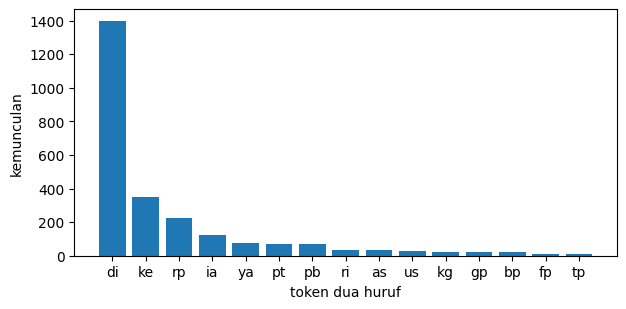

In [14]:
rows = [(w, n) for w, n in sorted(double.items(), key=lambda x: -x[1])
        if n >= 3][:15]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar([w for w, _ in rows], [n for _, n in rows])
ax.set_xlabel("token dua huruf")
ax.set_ylabel("kemunculan")
plt.show()

### Two-Letter Decision

Token dua huruf perlu diperiksa terpisah karena sebagian adalah kata singkat
nyata. Tabel konteksnya lalu dibandingkan dengan daftar stopword Sastrawi: token
yang terdaftar dipertahankan, sisanya dianggap artefak dan dipotong.

In [15]:
rows = []
for w, n in sorted(double.items(), key=lambda x: -x[1]):
    if n >= 3:
        rows.append({"token": w, "jumlah": n,
                     "konteks": context(list(df["isi_berita"]), w)})
pd.DataFrame(rows)

,token,jumlah,konteks
0,di,1398,"Marc Marquez Disebut di Puncak Karier, Bahasan C"
1,ke,347,Ai Ogura bersiap kembali ke arena MotoGP pada ...
2,rp,224,angga senilai lebih dari Rp 4 juta. Tas beruku...
3,ia,124,n dari maksimal 37 poin. Ia pun disebut sedang...
4,ya,78,ar lagi. Bagas juga sama ya sudah kita hajar s...
5,pt,72,"epada Djarum Foundation, PT Bank Rakyat Indone..."
6,pb,67,"a tim teknis khusus dari PB PASI, sehingga mat..."
7,ri,32,umni PPRA LXII Lemhannas RI itu. Tak hanya atl...
8,as,32,"ak atas hadiah 930 dolar AS, serta tambahan 15..."
9,us,31,Zverev Juara US Open 2026 Usai Kalahkan


In [16]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

id_stopwords = set(StopWordRemoverFactory().get_stop_words())
tokens_2huruf = [w for w, n in double.items() if n >= 3]
(pd.DataFrame({"token": tokens_2huruf,
               "jumlah": [double[w] for w in tokens_2huruf],
               "stopword Indonesia": [w in id_stopwords
                                      for w in tokens_2huruf]})
    .sort_values("jumlah", ascending=False))

,token,jumlah,stopword Indonesia
0,di,1398,True
4,ke,347,True
11,rp,224,False
1,ia,124,True
10,ya,78,True
36,pt,72,False
9,pb,67,False
19,ri,32,False
34,as,32,False
30,us,31,False


### Format Artifacts

Empat pola artefak format dicacah: URL, komposit alfanumerik atau kata berangka,
lambang mata uang, dan angka Romawi. Pola ini dilindungi utuh sebelum simbolnya
dibuang, agar nilainya tidak ikut terbaca sebagai term.

In [17]:
url_pattern = re.compile(r"(?:https?://|www\.|pic\.twitter\.com/)\S+")
alnum_pattern = re.compile(
    r"\b(?=[A-Za-z]*\d)[A-Za-z0-9][A-Za-z0-9.*-]*\b")
currency_pattern = re.compile(
    r"\bRp\d[\d.,]*\b|\bUS\$\d[\d.,]*\b|\b\$\d[\d.,]*\b|\bRp\b|\bUS\$\b")
roman_pattern = re.compile(
    r"\b(?:iii|iv|vi{0,3}|i[ivx]{0,2}|v|x{1,3}|xi{0,3})\b", re.IGNORECASE)


def first_match(pattern):
    for t in df["isi_berita"]:
        found = pattern.findall(t)
        if found:
            return found[0]
    return "-"


n_url = sum(len(url_pattern.findall(t)) for t in df["isi_berita"])
n_alnum = sum(len(alnum_pattern.findall(t)) for t in df["isi_berita"])
n_curr = sum(len(currency_pattern.findall(t)) for t in df["isi_berita"])
n_roman = sum(len(roman_pattern.findall(t)) for t in df["isi_berita"])

pd.DataFrame({
    "jenis": ["URL", "komposit alfanumerik dan angka", "lambang mata uang",
              "angka Romawi"],
    "kemunculan": [n_url, n_alnum, n_curr, n_roman],
    "contoh": [first_match(p) for p in (url_pattern, alnum_pattern,
                                        currency_pattern, roman_pattern)],
})

,jenis,kemunculan,contoh
0,URL,4,pic.twitter.com/9J4elWJLPZ
1,komposit alfanumerik dan angka,3508,2026
2,lambang mata uang,225,Rp
3,angka Romawi,56,II


In [18]:
def protect(text):
    text = url_pattern.sub(" ", text)
    text = currency_pattern.sub(" ", text)
    text = alnum_pattern.sub(" ", text)
    text = roman_pattern.sub(" ", text)
    return text.replace("\u2011", "-")


def clean_part1(text):
    text = normalize_letters(protect(text))
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    return " ".join(w for w in text.split() if len(w) >= 2)


corpus_clean_1 = [clean_part1(t) for t in df["isi_berita"]]
tokens_1 = [w.lower() for doc in corpus_clean_1 for w in doc.split()]
counts_1 = Counter(tokens_1)

pd.DataFrame({
    "kondisi": ["naif (teks dasar)", "setelah proteksi dan strip (min. 2 huruf)"],
    "token total": [len(naive), len(tokens_1)],
    "kata unik": [len(naive_counts), len(counts_1)],
    "token satu huruf": [sum(single.values()),
                         sum(n for w, n in counts_1.items() if len(w) == 1)],
    "token dua huruf": [sum(double.values()),
                        sum(n for w, n in counts_1.items() if len(w) == 2)],
})

,kondisi,token total,kata unik,token satu huruf,token dua huruf
0,naif (teks dasar),64919,7311,240,2773
1,setelah proteksi dan strip (min. 2 huruf),64260,7256,0,2444


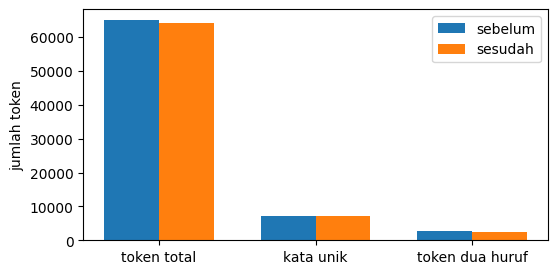

In [19]:
left = ["token total", "kata unik", "token dua huruf"]
before = [len(naive), len(naive_counts), sum(double.values())]
after = [len(tokens_1), len(counts_1),
         sum(n for w, n in counts_1.items() if len(w) == 2)]

fig, ax = plt.subplots(figsize=(6, 3))
w = 0.35
ax.bar([i - w / 2 for i in range(3)], before, width=w, label="sebelum")
ax.bar([i + w / 2 for i in range(3)], after, width=w, label="sesudah")
ax.set_xticks(range(3))
ax.set_xticklabels(left)
ax.set_ylabel("jumlah token")
ax.legend()
plt.show()

## Slang Standardization

Sebelum kata tidak baku dibakukan, dipastikan korpus ini berbahasa Indonesia:
sisipan asing dicek per kalimat dan per kata. Temuan di tahap ini menuntun
kebijakan untuk nama dan istilah yang tidak boleh ikut dinormalisasi.

In [20]:
import langid

sentences, article_ids = [], []
for _, row in df.iterrows():
    parts = [p.strip()
             for p in re.split(r"(?<=[.!?])\s+|\n+", row["isi_berita"])
             if p.strip()]
    sentences.extend(parts)
    article_ids.extend([row["id"]] * len(parts))

lang_labels = [langid.classify(s)[0] for s in sentences]
lang_counts = Counter(lang_labels)

(pd.DataFrame({"bahasa": list(lang_counts),
               "kalimat": list(lang_counts.values()),
               "proporsi": [f"{100 * k / len(sentences):.1f}%"
                            for k in lang_counts.values()]})
    .sort_values("kalimat", ascending=False))

,bahasa,kalimat,proporsi
0,id,3332,77.9%
1,ms,627,14.7%
9,en,67,1.6%
23,it,45,1.1%
2,es,32,0.7%
7,jv,23,0.5%
10,de,22,0.5%
6,eu,21,0.5%
5,tl,20,0.5%
28,da,10,0.2%


In [21]:
en_long = []
for s, lang, aid in zip(sentences, lang_labels, article_ids):
    if lang == "en" and len(s.split()) >= 8:
        en_long.append({"id": aid, "kalimat": s})
(pd.DataFrame(en_long, columns=["id", "kalimat"]).assign(kalimat=lambda d: d["kalimat"].str[:96] + "..."))

,id,kalimat
0,42,Vicky Lee Alison - Tegal (PB Sinar Mutiara) 4....
1,42,Karina Frederika Putri Loen - Kota Depok (PB C...
2,42,Azka Azfar Rabbani - Kabupaten Purworejo (PB G...
3,42,Ghian Ahza Danish Adinata - Kota Surakarta (PB...
4,66,Melengkapi front row ada Brian Uriarte dan Joe...
5,68,2 - 14.25-14.55 WIB - Moto2 Free Practice Nr....
6,68,2 - 15.10-15.40 WIB - MotoGP Free Practice Nr....
7,68,2 - 15.50-16.05 WIB - MotoGP Qualifying Nr....
8,68,1 - 16.15-16.30 WIB - MotoGP Qualifying Nr....
9,68,2 - 17.45-18.00 WIB - Moto3 Qualifying Nr....


### Word Probe

`langid` dilatih untuk teks panjang; pada kata tunggal pendek hasilnya sering
bias. Beberapa kata Indonesia yang sangat umum dicoba satu per satu sebagai
baseline: tabel di bawah menunjukkan label yang seharusnya jelas tetapi keliru.
Inilah alasan deteksi per-kata tidak dipakai.

In [22]:
token_in_en = Counter()
for s, lang in zip(sentences, lang_labels):
    if lang == "en" and len(s.split()) >= 8:
        token_in_en.update(re.findall(r"[A-Za-z]+", s.lower()))

corpus_words = Counter(
    w for t in df["isi_berita"] for w in re.findall(r"[A-Za-z]+", t.lower()))
cap_forms = Counter(
    w.lower() for t in df["isi_berita"]
    for w in re.findall(r"[A-Za-z]+", t) if w[0].isupper())

pd.DataFrame([{"kata": w, "di kalimat en": n, "total korpus": corpus_words[w],
               "muncul kapital": cap_forms[w]}
              for w, n in token_in_en.most_common(20)])

,kata,di kalimat en,total korpus,muncul kapital
0,wib,9,54,54
1,nr,8,9,9
2,qualifying,6,6,6
3,moto,5,55,53
4,pb,4,67,67
5,motogp,4,185,185
6,kota,2,60,41
7,free,2,4,4
8,practice,2,18,12
9,tahun,2,209,35


### Name Protection

Nama diri dicacah lewat bukti kapital di tengah kalimat: kata berawal huruf
besar yang tidak memulai kalimat hampir pasti nama orang atau lembaga. Judul
artikel menyatu dengan isi tanpa pemisah, sehingga kata berkapital di judul ikut
masuk daftar kandidat; ambang dominasi kapital pada tahap stemming nanti yang
menyaringnya. Daftarnya menjadi dasar perlindungan dari normalisasi slang dan
stemming.

In [23]:
def mid_sentence(text, pos):
    i = pos - 1
    while i >= 0 and text[i] in ' \n\t"\'":(':
        i -= 1
    return i >= 0 and text[i] not in '.!?;:(\u2013\u2014'


name_counts = Counter()
raw_counts = Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        raw_counts[w.lower()] += 1
        if (len(w) >= 3 and w[0].isupper()
                and mid_sentence(text, m.start())):
            name_counts[w.lower()] += 1

pd.DataFrame({
    "metrik": ["nama diri unik", "kemunculan total",
               "nama dengan >= 3 kemunculan"],
    "jumlah": [len(name_counts), sum(name_counts.values()),
               sum(1 for n in name_counts.values() if n >= 3)],
})

,metrik,jumlah
0,nama diri unik,3197
1,kemunculan total,13836
2,nama dengan >= 3 kemunculan,1044


In [24]:
pd.DataFrame([{"nama": w, "kemunculan": n}
              for w, n in name_counts.most_common(15)])

,nama,kemunculan
0,indonesia,346
1,jakarta,280
2,motogp,167
3,marquez,140
4,games,127
5,asian,106
6,purbaya,97
7,prabowo,94
8,san,93
9,marino,92


### Slang Candidates

Kandidat slang dicari lewat kamus indoNLP: token yang berubah oleh
`replace_slang` dicatat kemunculannya. Yang bertepatan muncul kapital di tengah
kalimat kemungkinan nama, sehingga diberi tanda untuk pemeriksaan manual.

In [25]:
from indoNLP.preprocessing import replace_slang

slang_hit = Counter()
cap_hit = Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        if replace_slang(w.lower()) != w.lower():
            slang_hit[w.lower()] += 1
            if w[0].isupper() and mid_sentence(text, m.start()):
                cap_hit[w.lower()] += 1

pd.DataFrame({
    "metrik": ["token kena kamus", "kemunculan berubah",
               "kemunculan nama diri (kapital tengah kalimat)"],
    "jumlah": [len(slang_hit), sum(slang_hit.values()), sum(cap_hit.values())],
})

,metrik,jumlah
0,token kena kamus,76
1,kemunculan berubah,336
2,kemunculan nama diri (kapital tengah kalimat),181


In [26]:
rows = []
for w in sorted(slang_hit, key=lambda x: -cap_hit[x]):
    rows.append({"token": w, "kemunculan": slang_hit[w],
                 "kapital tengah": cap_hit[w],
                 "padanan kamus": replace_slang(w)})
pd.DataFrame(rows[:15])

,token,kemunculan,kapital tengah,padanan kamus
0,m,31,29,sama
1,u,18,18,lu
2,minta,19,12,meminta
3,tp,12,12,tapi
4,q,10,10,ku
5,c,8,7,sih
6,am,7,7,sama
7,km,11,7,kamu
8,x,12,6,kali
9,d,5,5,di


### Ambiguous Context

Enam token kamus yang paling sering muncul dalam huruf kecil dilihat dari
konteks kalimatnya. Sebagian bisa jadi kata baku atau istilah yang kebetulan
mirip slang, sehingga token seperti itu dikecualikan dari normalisasi lewat
daftar `excluded_slang` pada cell berikutnya.

In [27]:
ambiguous = sorted(slang_hit,
                   key=lambda w: -(slang_hit[w] - cap_hit[w]))[:6]
pd.DataFrame([{"kata": w, "kemunculan": slang_hit[w],
               "padanan kamus": replace_slang(w),
               "konteks": context(list(df["isi_berita"]), w)}
              for w in ambiguous])

,kata,kemunculan,padanan kamus,konteks
0,nggak,34,enggak,agram @boldriders supaya nggak ketinggalan upd...
1,s,29,si,alking lunges dan farmer's carry. Wietrzyk tet...
2,gitu,10,begitu,saja. Yang bagus banget gitu. Bukan bagus saj...
3,udah,9,sudah,an teman-teman media kan udah punya data. Ngan...
4,minta,19,meminta,Hyrox Akhirnya Minta Maaf soal Insiden Atlet
5,kaya,9,kayak,pkan Aturan Larang Orang Kaya 'Minum' BBM Subs...


In [28]:
excluded_slang = {"minta", "pala", "fans"}
slang_changes = Counter()


def guarded_replace(text):
    changes = []
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        repl = replace_slang(w.lower())
        if repl == w.lower() or w.lower() in excluded_slang:
            continue
        before = text[max(0, m.start() - 6):m.start()]
        after = text[m.end():m.end() + 6]
        near_digit = bool(re.search(r"\d", before + after))
        looks_name = (w.isupper() or any(c.isupper() for c in w[1:])
                      or (w[:1].isupper() and w[1:].islower()
                          and mid_sentence(text, m.start())))
        two_letter = len(w) <= 2 and w.lower() not in id_stopwords
        if not (near_digit or looks_name or two_letter):
            changes.append((m.start(), m.end(), repl))
            slang_changes[w.lower()] += 1
    out = list(text)
    for s, e, r in reversed(changes):
        out[s:e] = list(r)
    return "".join(out)


def clean_full(text):
    text = normalize_letters(protect(text))
    text = guarded_replace(text)
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    words = [w for w in text.split() if len(w) >= 2]
    return " ".join(w for w in words
                    if not (len(w) == 2 and w.lower() not in id_stopwords))


final_docs = [clean_full(t).split() for t in df["isi_berita"]]
post_counts = Counter(w.lower() for doc in final_docs for w in doc)

pd.DataFrame([{"kata": w, "diubah": cnt, "padanan": replace_slang(w),
               "di korpus akhir": post_counts.get(replace_slang(w), 0)}
              for w, cnt in sorted(slang_changes.items())])

,kata,diubah,padanan,di korpus akhir
0,aja,3,saja,50
1,dapet,1,dapat,150
2,dibiarin,1,dibiarkan,3
3,gak,1,enggak,62
4,gimana,3,bagaimana,31
5,gini,1,begini,4
6,gitu,10,begitu,41
7,hub,4,hubungan,12
8,ikutin,1,mengikuti,34
9,kaya,7,kayak,9


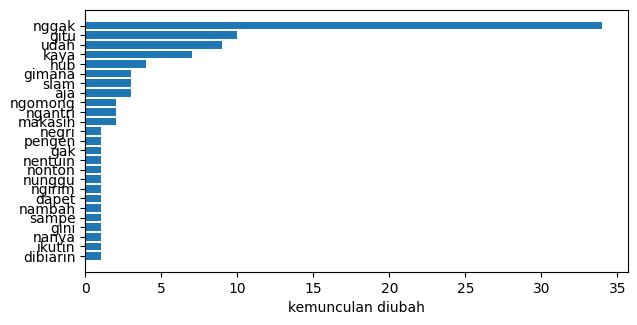

In [29]:
fig, ax = plt.subplots(figsize=(7, 3.4))
rows = sorted(slang_changes.items(), key=lambda x: -x[1])
ax.barh([w for w, _ in rows], [n for _, n in rows])
ax.set_xlabel("kemunculan diubah")
ax.invert_yaxis()
plt.show()

In [30]:
pd.DataFrame([{"kata": w, "kemunculan": post_counts[w],
               "padanan kamus": replace_slang(w)}
              for w in sorted(post_counts)
              if replace_slang(w) != w]).head(20)

,kata,kemunculan,padanan kamus
0,ade,2,adek
1,bhs,2,bahasa
2,bkn,1,bukan
3,cape,1,capek
4,dapet,1,dapat
5,dengerin,1,mendengarkan
6,fans,1,fan
7,indo,1,indonesia
8,kaya,2,kayak
9,kek,2,kayak


## POS Tagging

Setiap token dilabeli kategori gramatikal sebelum stopword dibuang. Tagger
dilatih pada kalimat utuh: kata fungsi seperti *dan* atau *di* memberi konteks
untuk menebak kata di sekitarnya, dan bentuk infleksi (berimbuhan) adalah masukan
aslinya. Dipakai model RoBERTa bahasa Indonesia (tagset POSP) lewat
`transformers`. Model hanya menerima 512 subword per panggilan, jadi dokumen
panjang dipecah menjadi potongan yang diproses bergantian; dengan agregasi, satu
label keluar untuk setiap kata.

In [31]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from transformers import pipeline
import torch
import logging
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="Asking to truncate to max_length")
warnings.filterwarnings("ignore",
                        message="Tokenizer does not support real words")
pos_pipe = pipeline(
    "token-classification",
    model="w11wo/indonesian-roberta-base-posp-tagger",
    aggregation_strategy="average",
    device=0 if torch.cuda.is_available() else -1,
)

c:\Users\zulfr\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zulfr\.cache\huggingface\hub\models--w11wo--indonesian-roberta-base-posp-tagger. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:01<00:00, 166.57it/s]


In [34]:
wsize_budget = 400
tok = pos_pipe.tokenizer
assert tok is not None
tag_total = Counter()
sample_rows = []
annotations = []
sample_pos = set(df.drop_duplicates("label").index + 1)

piece_len = [[len(tok(t, add_special_tokens=False).input_ids) for t in d]
             for d in final_docs]

for doc_idx, (tokens, plen) in enumerate(zip(final_docs, piece_len),
                                         start=1):
    windows, cur, acc = [], [], 0
    for t, p in zip(tokens, plen):
        if cur and acc + p > wsize_budget:
            windows.append(cur)
            cur, acc = [t], p
        else:
            cur.append(t)
            acc += p
    if cur:
        windows.append(cur)
    tags = []
    for win in windows:
        out = pos_pipe([win], is_split_into_words=True)[0]
        for hit in out:
            tag_total[hit["entity_group"]] += 1
            tags.append(hit["entity_group"])
    annotations.append(tags)
    if doc_idx in sample_pos:
        sample_rows.extend({"id": doc_idx, "token": w, "tag": t}
                           for w, t in zip(tokens[:12], tags[:12]))

pd.DataFrame(sample_rows)

,id,token,tag
0,1,Marc,NNP
1,1,Marquez,NNP
2,1,Disebut,VBP
3,1,di,PPO
4,1,Puncak,NNO
5,1,Karier,NNO
6,1,Bahasan,NNO
7,1,Cedera,ADJ
8,1,Tak,NEG
9,1,Lagi,ADV


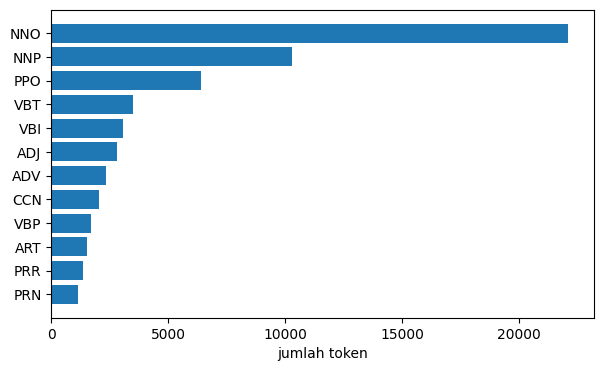

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
rows = tag_total.most_common(12)
ax.barh([t for t, _ in rows], [n for _, n in rows])
ax.set_xlabel("jumlah token")
ax.invert_yaxis()
plt.show()

## Stopword Removal

Stopword adalah kata umum yang hampir tanpa makna dan muncul di hampir semua
dokumen (misal *yang*, *di*, *dan*). Daftar Sastrawi dipakai untuk membuangnya,
sehingga kosakata mengecil dan bobot TF-IDF nanti terfokus pada kata pembeda.

In [36]:
docs_no_stop = [[w for w in d if w.lower() not in id_stopwords]
                for d in final_docs]
removed = Counter(w.lower() for d in final_docs for w in d
                  if w.lower() in id_stopwords)
before_tokens = sum(len(d) for d in final_docs)
before_uniq = len({w.lower() for d in final_docs for w in d})
after_tokens = sum(len(d) for d in docs_no_stop)
after_uniq = len({w.lower() for d in docs_no_stop for w in d})

pd.DataFrame({
    "metrik": ["token total", "kata unik", "stopword dihapus",
               "jenis stopword"],
    "sebelum": [before_tokens, before_uniq, "-", "-"],
    "sesudah": [after_tokens, after_uniq, sum(removed.values()), len(removed)],
})

,metrik,sebelum,sesudah
0,token total,63771,48007
1,kata unik,7161,7054
2,stopword dihapus,-,15764
3,jenis stopword,-,107


In [37]:
pd.DataFrame([{"kata": w, "dihapus": n}
              for w, n in removed.most_common(20)])

,kata,dihapus
0,di,1398
1,yang,1347
2,dan,1267
3,ini,706
4,dari,699
5,dengan,687
6,untuk,565
7,dalam,463
8,juga,423
9,pada,422


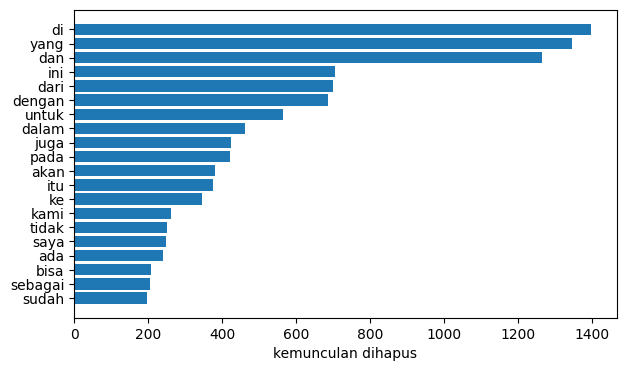

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))
rows = removed.most_common(20)
ax.barh([w for w, _ in rows], [n for _, n in rows])
ax.set_xlabel("kemunculan dihapus")
ax.invert_yaxis()
plt.show()

In [39]:
sample_ids = list(df.drop_duplicates("label")["id"])
pd.DataFrame({
    "id": sample_ids,
    "sebelum": [" ".join(final_docs[i - 1][:16]) for i in sample_ids],
    "sesudah": [" ".join(docs_no_stop[i - 1][:16]) for i in sample_ids],
})

,id,sebelum,sesudah
0,1,Marc Marquez Disebut di Puncak Karier Bahasan ...,Marc Marquez Disebut Puncak Karier Bahasan Ced...
1,101,Penempatan Manajer Kopdes Ditargetkan Paling L...,Penempatan Manajer Kopdes Ditargetkan Paling L...


## Stemming

Stemming memotong afiks supaya kata sekeluarga kembali ke kata dasar, misal
`menambahkan` menjadi `tambah`. Kosakata mengecil dan dokumen dengan bentuk kata
berbeda bisa saling cocok. Risikonya over-stemming (kata berbeda arti tersatu),
karena itu nama diri dilindungi lebih dulu.

In [41]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.Stemmer.Stemmer import Stemmer
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary
from functools import lru_cache

words = StemmerFactory().get_words()
stemmer = Stemmer(ArrayDictionary(words))


@lru_cache(maxsize=None)
def stem_word(token):
    return stemmer.stem(token)

In [42]:
protected = {w for w, n in name_counts.items()
             if n >= 5 and n >= 0.5 * raw_counts[w]}


def stem_doc(words):
    out = []
    for w in words:
        w = w.lower()
        out.append(w if w in protected else stem_word(w))
    return out


docs_stem = [stem_doc(d) for d in docs_no_stop]
st_tokens = sum(len(d) for d in docs_stem)
st_uniq = len({w for d in docs_stem for w in d})

pd.DataFrame({
    "metrik": ["token total", "kata unik"],
    "sebelum": [after_tokens, after_uniq],
    "sesudah": [st_tokens, st_uniq],
})

,metrik,sebelum,sesudah
0,token total,48007,48007
1,kata unik,7054,4970


In [43]:
stem_map = Counter()
for a, b in zip([w for d in docs_no_stop for w in d],
                [w for d in docs_stem for w in d]):
    if a != b:
        stem_map[(a, b)] += 1

pd.DataFrame([{"token": a, "stem": b, "kemunculan": n}
              for (a, b), n in stem_map.most_common(20)])

,token,stem,kemunculan
0,Indonesia,indonesia,361
1,tersebut,sebut,336
2,menjadi,jadi,336
3,Jakarta,jakarta,288
4,MotoGP,motogp,185
5,Marquez,marquez,163
6,Games,games,127
7,Marc,marc,121
8,Asian,asian,116
9,Prabowo,prabowo,116


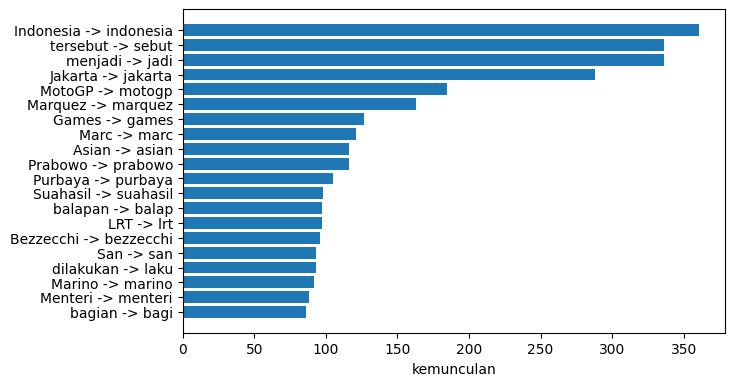

In [44]:
fig, ax = plt.subplots(figsize=(7, 4.2))
rows = stem_map.most_common(20)
ax.barh([f"{a} -> {b}" for (a, b), _ in rows], [n for _, n in rows])
ax.set_xlabel("kemunculan")
ax.invert_yaxis()
plt.show()

### Name Guard

Kandidat nama dihimpun dari aturan kapital di tengah kalimat, lalu dilindungi
bila kapital itu dominan (minimal lima kemunculan dan setengah dari semua bentuk
tulisannya). Nama yang kata dasarnya runtuh saat di-stem, seperti pada tabel di
bawah, menunjukkan mengapa perlindungan ini perlu.

In [45]:
risky = [(w, stem_word(w)) for w in sorted(protected)
         if stem_word(w) != w]
pd.DataFrame(risky, columns=["nama", "runtuh menjadi"])

,nama,runtuh menjadi
0,anggaran,anggar
1,asian,asi
2,bali,bal
3,bekasi,bekas
4,dicopot,copot
5,hadi,had
6,kementerian,menteri
7,kepresidenan,presiden
8,keuangan,uang
9,maluku,malu


In [46]:
top_names = {w for w, _ in name_counts.most_common(80)}
altered = [(a, b) for (a, b), _ in stem_map.items()
           if b != a.lower() and a.lower() in top_names]
pd.DataFrame({
    "metrik": ["nama dilindungi", "kata unik nama teratas berubah"],
    "nilai": [len(protected), len(altered)],
})

,metrik,nilai
0,nama dilindungi,514
1,kata unik nama teratas berubah,4


## Unique Word Extraction

Sklearn menghitung seluruh kata unik dari token hasil stemming. Di samping total
kosakata, kata unik juga dihitung per label dan irisannya, untuk melihat seberapa
berbeda kosakata sport dan finance sebelum tabel fitur disusun.

In [47]:
from sklearn.feature_extraction.text import CountVectorizer

counter = CountVectorizer(token_pattern=r"(?u)\b\w\w+\b")
counter.fit([" ".join(d) for d in docs_stem])
vocab = counter.get_feature_names_out()

sport_vocab = {w for d, lbl in zip(docs_stem, df["label"])
               if lbl == "sport" for w in set(d)}
finance_vocab = {w for d, lbl in zip(docs_stem, df["label"])
                 if lbl == "finance" for w in set(d)}

pd.DataFrame({
    "kelompok": ["seluruh korpus", "label sport", "label finance",
                 "dipakai kedua label"],
    "kata unik": [len(vocab), len(sport_vocab), len(finance_vocab),
                  len(sport_vocab & finance_vocab)],
})

,kelompok,kata unik
0,seluruh korpus,4970
1,label sport,3090
2,label finance,3086
3,dipakai kedua label,1206


## TF-IDF Representation

TF-IDF (term frequency × inverse document frequency) memberi bobot besar pada
kata yang khas dalam satu dokumen dan bobot kecil pada kata umum, sehingga lebih
tegas daripada sekadar frekuensi. Vektor hasilnya menjadi dataset siap model dan
disimpan dalam bentuk sparse; tabel tampilan dibuat terpisah karena matriks
padatnya lebih mudah diperiksa.

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w\w+\b")
X = vectorizer.fit_transform([" ".join(d) for d in docs_stem])

pd.DataFrame({
    "metrik": ["dokumen", "fitur", "entri bukan nol (nnz)"],
    "nilai": [X.shape[0], X.shape[1], X.nnz],
})

,metrik,nilai
0,dokumen,200
1,fitur,4970
2,entri bukan nol (nnz),25786


### Final TF-IDF Table

Matriks sparse sulit dibaca manusia, jadi tabel di bawah diubah ke bentuk padat:
baris dokumen, kolom kata, dan label kelas di kolom terakhir. Ukuran tabel
dicetak sebagai bukti bahwa label memang ikut tercantum. Kolom kelas diberi nama
`label_kelas` agar tidak bentrok dengan kata yang mungkin menjadi fitur TF-IDF.

In [49]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(X.toarray(), index=df["id"], columns=feature_names)
df_tfidf["label_kelas"] = df["label"].values
df_tfidf.shape

(200, 4971)

In [50]:
word_freq = np.asarray(X.sum(axis=0)).ravel()
top_idx = np.argsort(-word_freq)[:10]
pd.DataFrame({"kata": feature_names[top_idx],
              "bobot total": word_freq[top_idx]})

,kata,bobot total
0,jadi,6.230627
1,marquez,6.146429
2,motogp,6.047365
3,jakarta,5.931436
4,indonesia,5.918221
5,balap,5.791675
6,sebut,4.865899
7,games,4.664614
8,marc,4.515614
9,poin,4.468262


In [51]:
df_tfidf[[feature_names[i] for i in top_idx] + ["label_kelas"]].head()

,jadi,marquez,motogp,jakarta,indonesia,balap,sebut,games,marc,poin,label_kelas
id,,,,,,,,,,,
1,0.044043,0.070448,0.100059,0.000000,0.000000,0.061709,0.068965,0.000000,0.498898,0.228751,sport
2,0.047550,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,sport
3,0.019656,0.000000,0.267932,0.000000,0.000000,0.185896,0.011542,0.000000,0.000000,0.043752,sport
4,0.011670,0.000000,0.000000,0.000000,0.072262,0.000000,0.041114,0.000000,0.000000,0.000000,sport
5,0.070585,0.000000,0.000000,0.016895,0.109271,0.000000,0.059211,0.048387,0.000000,0.000000,sport


### Sparse Check

Tabel padat hanya untuk tampilan; matriks asli tetap sparse. Sebagai bukti,
dihitung jumlah sel yang nilainya lebih dari nol: hasilnya harus sama dengan
entri bukan nol (nnz) pada tabel metrik sebelumnya.

In [52]:
(df_tfidf.drop(columns="label_kelas").to_numpy() > 0).sum()

np.int64(25786)

In [53]:
col_tot = np.asarray(X.sum(axis=0)).ravel()
col_freq = np.asarray((X > 0).sum(axis=0)).ravel()
informative = [i for i in np.argsort(-col_tot) if col_freq[i] >= 2][:8]

rows = [0, 45, 99, 100, 150, 199]
sub = pd.DataFrame(
    X[rows][:, informative].toarray(),
    index=[f"{df['id'].iloc[i]}-{df['label'].iloc[i]}" for i in rows],
    columns=[feature_names[i] for i in informative],
)
sub

,jadi,marquez,motogp,jakarta,indonesia,balap,sebut,games
1-sport,0.044043,0.070448,0.100059,0.000000,0.000000,0.061709,0.068965,0.0
46-sport,0.014216,0.238758,0.258372,0.000000,0.000000,0.149386,0.000000,0.0
100-sport,0.000000,0.000000,0.000000,0.000000,0.025265,0.000000,0.000000,0.0
101-finance,0.013472,0.000000,0.000000,0.000000,0.000000,0.000000,0.031643,0.0
151-finance,0.014751,0.000000,0.000000,0.321301,0.000000,0.000000,0.086617,0.0
200-finance,0.009637,0.000000,0.000000,0.000000,0.014918,0.000000,0.000000,0.0


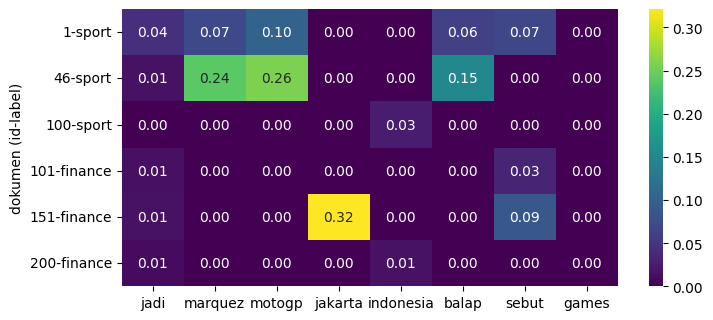

In [54]:
fig, ax = plt.subplots(figsize=(8, 3.6))
sns.heatmap(sub.values, cmap="viridis", annot=True, fmt=".2f",
            xticklabels=sub.columns.astype(str).tolist(),
            yticklabels=sub.index.astype(str).tolist(), ax=ax)
ax.set_ylabel("dokumen (id-label)")
plt.show()

In [55]:
import os
import scipy.sparse as sp

sp.save_npz("tfidf_sparse.npz", X)
pd.Series(feature_names).to_csv("tfidf_features.txt",
                                index=False, header=False)
pd.DataFrame({"id": df["id"], "label": df["label"]}).to_csv(
    "tfidf_docs.csv", index=False)

pd.DataFrame({
    "berkas": ["tfidf_sparse.npz", "tfidf_features.txt", "tfidf_docs.csv"],
    "ukuran (byte)": [os.path.getsize("tfidf_sparse.npz"),
                      os.path.getsize("tfidf_features.txt"),
                      os.path.getsize("tfidf_docs.csv")],
})

,berkas,ukuran (byte)
0,tfidf_sparse.npz,164718
1,tfidf_features.txt,40410
2,tfidf_docs.csv,2302


## Dimensionality Reduction

Matriks TF-IDF berdimensi ribuan dan sparse, sehingga membawa banyak dimensi
kosong yang bakal memperlambat dan melemahkan model selanjutnya. PCA
memproyeksikan matriks ke komponen utama yang saling bebas: dua komponen dulu
digunakan untuk melihat sebaran awal, lalu seluruh komponen untuk membaca
seberapa cepat varians terkumpul.

In [56]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2, random_state=42)
Z = pca2.fit_transform(X.toarray())
evr2 = pca2.explained_variance_ratio_

pd.DataFrame({
    "komponen": ["PC1", "PC2", "jumlah"],
    "proporsi varians": [f"{evr2[0]:.4f}", f"{evr2[1]:.4f}",
                         f"{evr2.sum():.4f}"],
})

,komponen,proporsi varians
0,PC1,0.0463
1,PC2,0.0333
2,jumlah,0.0796


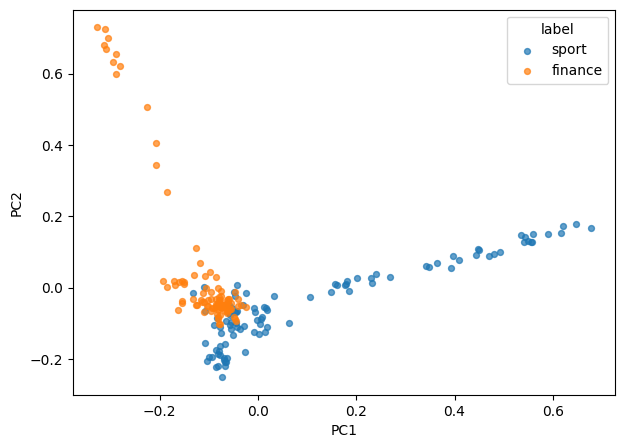

In [57]:
fig, ax = plt.subplots(figsize=(7, 5))
for label in ["sport", "finance"]:
    mask = (df["label"] == label).to_numpy()
    ax.scatter(Z[mask, 0], Z[mask, 1], s=18, alpha=0.7, label=label)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="label")
plt.show()

### Cumulative Variance

Tujuan akhirnya mereduksi ke dimensi di bawah 500. Karena dokumen hanya 200,
komponen maksimum yang bisa dihitung juga 200, sehingga seluruh titik pada kurva
otomatis memenuhi target itu; angka per ambang dihitung dari output di bawah.

In [58]:
max_comp = min(X.shape)
pca_all = PCA(n_components=max_comp, random_state=42).fit(X.toarray())
cum = pca_all.explained_variance_ratio_.cumsum()

pd.DataFrame([{"target varians": t,
               "komponen dibutuhkan": int((cum >= t).argmax()) + 1,
               "komponen < 500": int((cum >= t).argmax()) + 1 < 500}
              for t in [0.5, 0.8, 0.9, 0.95]])

,target varians,komponen dibutuhkan,komponen < 500
0,0.50,46,True
1,0.80,109,True
2,0.90,139,True
3,0.95,159,True


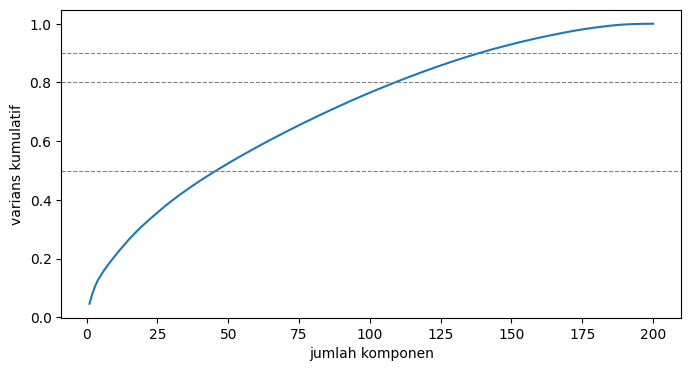

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum) + 1), cum)
for t in [0.5, 0.8, 0.9]:
    ax.axhline(t, color="gray", ls="--", lw=0.8)
ax.set_xlabel("jumlah komponen")
ax.set_ylabel("varians kumulatif")
plt.show()

In [60]:
chosen = int((cum >= 0.9).argmax()) + 1

pd.DataFrame({
    "metrik": ["fitur TF-IDF", "komponen terpilih (90%)",
               "pengurangan dimensi", "varians dua komponen"],
    "nilai": [X.shape[1], chosen,
              f"{1 - chosen / X.shape[1]:.1%}", f"{evr2.sum():.2%}"],
})

,metrik,nilai
0,fitur TF-IDF,4970
1,komponen terpilih (90%),139
2,pengurangan dimensi,97.2%
3,varians dua komponen,7.96%


In [61]:
from IPython.display import Markdown, display


def ribu(n):
    return f"{n:,}".replace(",", ".")


def desimal(x, d=2):
    return f"{x:.{d}f}".replace(".", ",")


pct_id = desimal(100 * lang_counts.get("id", 0) / len(sentences), 1)

display(Markdown(f"""## Conclusion

Seluruh proses dapat diringkas sebagai satu rantai sebab-akibat. Eksplorasi
menemukan sisa antarmuka detik.com ({ribu(n_boiler)} artikel) dan artefak format
(URL, mata uang, komposit berangka, angka Romawi, token satu-dua huruf) yang
menentukan aturan pembersihan; deteksi bahasa menegaskan korpus ini berita
Indonesia ({pct_id}% kalimat berlabel Indonesia) sehingga sisipan asing dianggap
nama atau istilah; slang dibakukan dengan nama diri yang dilindungi. Sebelum
stopword dibuang, {ribu(before_tokens)} token dilabeli kategori gramatikal
sebagai anotasi analisis. Stopword dan stemming mengecilkan kosakata dari
{ribu(before_uniq)} kata unik menjadi {ribu(st_uniq)}, dan hasilnya dipetakan
menjadi matriks TF-IDF {X.shape[0]} dokumen x {ribu(X.shape[1])} fitur yang
disimpan ke `data/`. PCA mempertahankan hingga 90% varians dengan {chosen}
komponen (di bawah 500), sedangkan proyeksi dua komponen hanya menahan
{desimal(100 * evr2.sum())}% varians, cukup untuk gambaran awal sebaran, tidak
untuk analisis lanjutan."""))

## Conclusion

Seluruh proses dapat diringkas sebagai satu rantai sebab-akibat. Eksplorasi
menemukan sisa antarmuka detik.com (197 artikel) dan artefak format
(URL, mata uang, komposit berangka, angka Romawi, token satu-dua huruf) yang
menentukan aturan pembersihan; deteksi bahasa menegaskan korpus ini berita
Indonesia (77,9% kalimat berlabel Indonesia) sehingga sisipan asing dianggap
nama atau istilah; slang dibakukan dengan nama diri yang dilindungi. Sebelum
stopword dibuang, 63.771 token dilabeli kategori gramatikal
sebagai anotasi analisis. Stopword dan stemming mengecilkan kosakata dari
7.161 kata unik menjadi 4.970, dan hasilnya dipetakan
menjadi matriks TF-IDF 200 dokumen x 4.970 fitur yang
disimpan ke `data/`. PCA mempertahankan hingga 90% varians dengan 139
komponen (di bawah 500), sedangkan proyeksi dua komponen hanya menahan
7,96% varians, cukup untuk gambaran awal sebaran, tidak
untuk analisis lanjutan.